In [1]:
import pandas as pd
import matplotlib.pyplot as plt
# Load the data from the CSV file
df = pd.read_csv(
    "LUMEN_DS.csv",
    sep="|",
    quotechar='"',
    encoding="utf-16",
    low_memory=False,
)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1294962 entries, 0 to 1294961
Data columns (total 33 columns):
 #   Column                               Non-Null Count    Dtype  
---  ------                               --------------    -----  
 0   Manufacturing Region                 1254453 non-null  str    
 1   Manufacturing Location Code          1255003 non-null  str    
 2   Intercompany                         1294962 non-null  str    
 3   CustomerID                           1294962 non-null  int64  
 4   Customer industry                    1294962 non-null  str    
 5   Customer Region                      1294859 non-null  str    
 6   Customer First Invoice Date          1294962 non-null  str    
 7   Top Customer Group                   1294962 non-null  str    
 8   Item Code                            1294907 non-null  str    
 9   Product family                       1294962 non-null  str    
 10  Product group                        1126302 non-null  str    
 11  Price las

Using columns -> customer: CustomerID , group: Product group , quantity (detected): Invoiced qty (shipped)
Found 9946 customers with more than 10 total purchased products.
Found 9946 customers with more than 10 total purchased products.


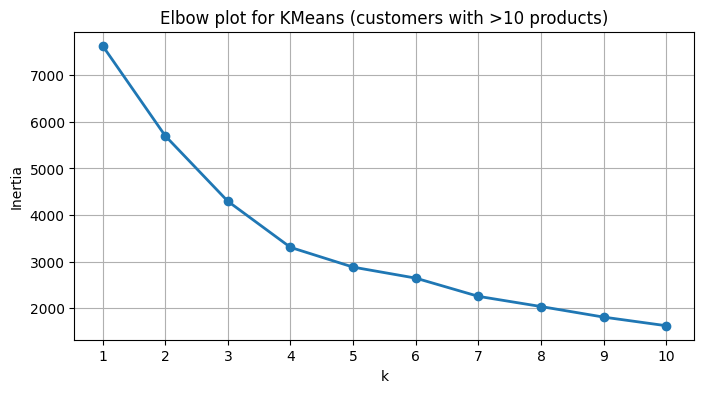

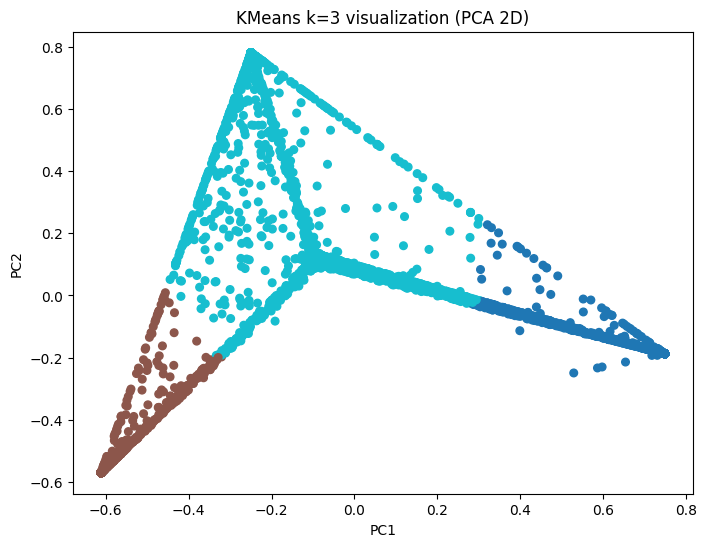

Percent vector shape (customers x product_groups): (9946, 33)


Product group,2016-11-02 00:00:00,2018-09-01 00:00:00,PC001,PC002,PC003,PC004,PC005,PC006,PC007,PC008,...,PC022,PC023,PC024,PC025,PC026,PC028,PC029,PC030,SF001,SF002
CustomerID,,,,,,,,,,,,,,,,,,,,,
-99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.098214,...,0.0,0.0,0.0,0.0,0.901554,0.0,0.0,0.0,0.0,0.0
13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


In [3]:
# Build customer vectors (only customers with > 10 total products)
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Use explicit columns provided by the user
cols = list(df.columns)
cust_col = 'CustomerID'
group_col = 'Product group'
# try to detect a quantity column, otherwise assume each row = 1
qty_col = next((c for c in cols if 'qty' in c.lower() or 'quantity' in c.lower() or 'count' in c.lower() or 'units' in c.lower()), None)

print('Using columns -> customer:', cust_col, ', group:', group_col, ', quantity (detected):', qty_col)

# Validate required columns exist
if cust_col not in df.columns:
    raise ValueError(f'Column "{cust_col}" not found in dataframe. Available columns: {cols}')
if group_col not in df.columns:
    raise ValueError(f'Column "{group_col}" not found in dataframe. Available columns: {cols}')

# If no quantity column, assume each row represents a single product (qty = 1)
working_df = df.copy()
if qty_col is None:
    working_df['_qty'] = 1
    qty_col = '_qty'

# Aggregate counts per customer x group
agg = working_df.groupby([cust_col, group_col])[qty_col].sum().reset_index()
# total per customer
totals = agg.groupby(cust_col)[qty_col].sum().reset_index().rename(columns={qty_col: 'total_qty'})
# filter customers with > 10 products
customers_over10 = totals.loc[totals['total_qty'] > 10, cust_col].unique()
print(f'Found {len(customers_over10)} customers with more than 10 total purchased products.')

agg_filtered = agg[agg[cust_col].isin(customers_over10)]
# pivot to get one vector per customer (counts per group)
pivot = agg_filtered.pivot_table(index=cust_col, columns=group_col, values=qty_col, fill_value=0)
# convert counts into percentages of that customer's total purchases
percent = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)

# Elbow plot: compute inertia for k = 1..10
inertias = []
Ks = range(1, 11)
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(percent)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(Ks), inertias, 'o-', linewidth=2)
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow plot for KMeans (customers with >10 products)')
plt.xticks(list(Ks))
plt.grid(True)
plt.show()

# Optional: visualize clusters in 2D using PCA for a chosen k (change k_vis if you want another)
k_vis = 3  # change this after inspecting elbow plot
if len(percent) >= k_vis:
    km_vis = KMeans(n_clusters=k_vis, random_state=42, n_init=10)
    labels = km_vis.fit_predict(percent)
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(percent)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(coords[:, 0], coords[:, 1], c=labels, cmap='tab10', s=30)
    plt.title(f'KMeans k={k_vis} visualization (PCA 2D)')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.grid(False)
    plt.show()
else:
    print('Not enough customers to visualize for k=', k_vis)

# Show the shape of the percent vectors (customers x product_groups) and first rows
print('Percent vector shape (customers x product_groups):', percent.shape)
display(percent.head())

In [4]:
# Display centroids and cluster sizes for k=3

# Check if km_vis and percent variables exist from the previous cell
if 'km_vis' in locals() and 'percent' in locals():
    # Get cluster centers (centroids)
    centroids = km_vis.cluster_centers_
    
    # Get cluster labels for each customer
    labels = km_vis.labels_

    # Count number of elements in each cluster
    cluster_counts = pd.Series(labels).value_counts().sort_index()
    
    print("Number of customers in each cluster:")
    for i, count in enumerate(cluster_counts):
        print(f"Cluster {i}: {count} customers")

    # Create a DataFrame for the centroids with product groups as columns
    centroid_df = pd.DataFrame(centroids, columns=percent.columns)

    print("\nCluster Centroids (Top 5 product groups for each cluster):")
    for i in range(len(centroid_df)):
        print(f"\n----- Centroid for Cluster {i} -----")
        # Sort the product groups for the current centroid by percentage, in descending order
        top_groups = centroid_df.iloc[i].sort_values(ascending=False)
        # Display the top 5
        print(top_groups.head(5))
else:
    print("Please run the previous cell first to perform clustering and define km_vis.")


Number of customers in each cluster:
Cluster 0: 2624 customers
Cluster 1: 1951 customers
Cluster 2: 5371 customers

Cluster Centroids (Top 5 product groups for each cluster):

----- Centroid for Cluster 0 -----
Product group
PC010    0.947481
PC001    0.018760
PC021    0.007406
PC011    0.005358
PC016    0.004200
Name: 0, dtype: float64

----- Centroid for Cluster 1 -----
Product group
PC013    0.956463
PC026    0.008763
PC025    0.008430
PC014    0.007660
SF002    0.005818
Name: 1, dtype: float64

----- Centroid for Cluster 2 -----
Product group
PC026    0.272333
PC022    0.092260
PC001    0.091334
PC021    0.056020
PC025    0.055530
Name: 2, dtype: float64


In [5]:
# Perform PCA and display the top 3 components

if 'percent' in locals():
    # Initialize PCA with 3 components
    pca_3 = PCA(n_components=3, random_state=42)
    
    # Fit PCA on the percentage vectors
    pca_3.fit(percent)
    
    # Create a DataFrame for the principal components
    components_df = pd.DataFrame(pca_3.components_, columns=percent.columns)
    
    print("Explained Variance Ratio by each component:")
    for i, variance in enumerate(pca_3.explained_variance_ratio_):
        print(f"  Component {i+1}: {variance:.4f} ({variance:.2%})")
        
    print(f"\nTotal variance explained by 3 components: {sum(pca_3.explained_variance_ratio_):.4f} ({sum(pca_3.explained_variance_ratio_):.2%})")

    print("\nTop 10 influential product groups for each Principal Component:")
    for i in range(len(components_df)):
        print(f"\n----- Principal Component {i+1} -----")
        # Sort by absolute value to see the most influential groups, regardless of direction
        top_groups = components_df.iloc[i].reindex(components_df.iloc[i].abs().sort_values(ascending=False).index)
        print(top_groups.head(10))
else:
    print("Please run the cell that defines the 'percent' DataFrame first.")


Explained Variance Ratio by each component:
  Component 1: 0.2832 (28.32%)
  Component 2: 0.1980 (19.80%)
  Component 3: 0.1119 (11.19%)

Total variance explained by 3 components: 0.5931 (59.31%)

Top 10 influential product groups for each Principal Component:

----- Principal Component 1 -----
Product group
PC010    0.831329
PC013   -0.528474
PC026   -0.166685
PC022   -0.024041
PC025   -0.020317
PC014   -0.013830
PC019   -0.013432
PC012   -0.010584
PC002   -0.009317
PC009   -0.008275
Name: 0, dtype: float64

----- Principal Component 2 -----
Product group
PC026    0.688857
PC013   -0.663920
PC010   -0.280758
PC022    0.044769
PC001    0.037046
PC025    0.021987
PC021    0.020588
PC019    0.018485
PC009    0.018342
PC012    0.016784
Name: 1, dtype: float64

----- Principal Component 3 -----
Product group
PC026    0.642571
PC013    0.445507
PC010    0.393546
PC022   -0.310767
PC001   -0.264964
PC021   -0.129187
PC009   -0.102531
PC025   -0.086201
PC019   -0.086085
PC012   -0.077358
Name

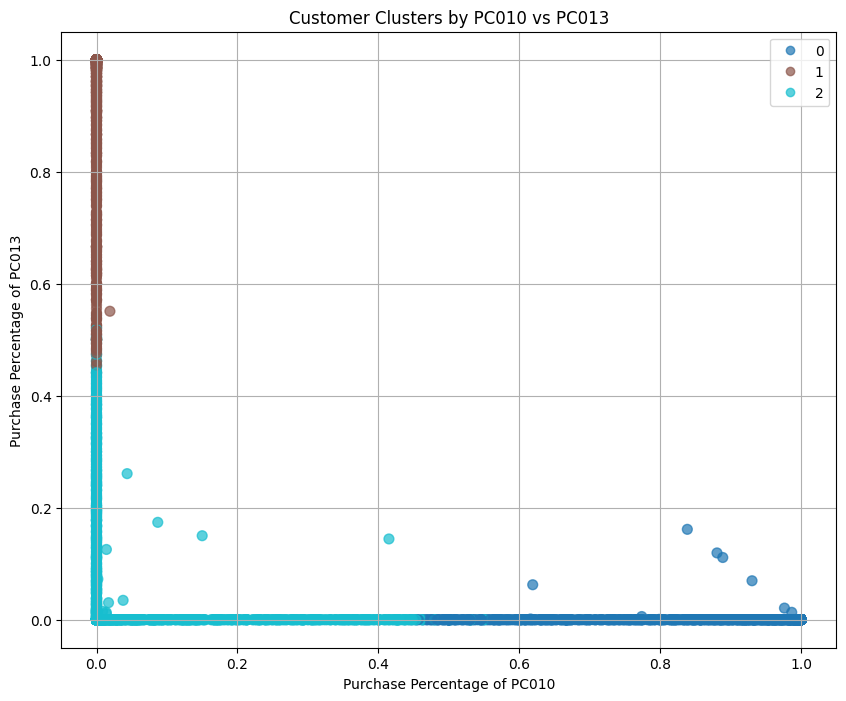

In [6]:
# Plot clusters using PC010 and PC013 as coordinates

# Check if the necessary variables from previous cells exist
if 'percent' in locals() and 'labels' in locals():
    
    # Define the columns to use for the plot
    x_axis_col = 'PC010'
    y_axis_col = 'PC013'
    
    # Check if the specified columns exist in the DataFrame
    if x_axis_col in percent.columns and y_axis_col in percent.columns:
        plt.figure(figsize=(10, 8))
        
        # Create a scatter plot
        scatter = plt.scatter(
            percent[x_axis_col], 
            percent[y_axis_col], 
            c=labels, 
            cmap='tab10', 
            s=50,
            alpha=0.7
        )
        
        plt.title(f'Customer Clusters by {x_axis_col} vs {y_axis_col}')
        plt.xlabel(f'Purchase Percentage of {x_axis_col}')
        plt.ylabel(f'Purchase Percentage of {y_axis_col}')
        
        # Create a legend for the clusters
        plt.legend(handles=scatter.legend_elements()[0], labels=range(k_vis))
        
        plt.grid(True)
        plt.show()
    else:
        print(f"Error: One or both columns '{x_axis_col}', '{y_axis_col}' not found in the data.")
        print(f"Available columns are: {percent.columns.tolist()}")

else:
    print("Please make sure to run the previous cells to define the 'percent' DataFrame and 'labels' from clustering.")


In [7]:
import plotly.express as px
import pandas as pd

# Check if the necessary variables from previous cells are available
if 'percent' in locals() and 'labels' in locals() and 'coords' in locals() and 'cust_col' in locals():

    # --- 1. Prepare data for hover tooltips ---
    
    # Function to get top 5 product groups for a single customer (row)
    def get_top_5_groups(row):
        # Filter for non-zero percentages, sort, and take the top 5
        top_groups = row[row > 0].sort_values(ascending=False).head(5)
        # Format as "GroupName: XX.X%"
        return '<br>'.join([f'{idx}: {val:.1%}' for idx, val in top_groups.items()])

    # Apply the function to each customer row to create the hover text
    # This can take a moment if there are many customers
    hover_text = percent.apply(get_top_5_groups, axis=1)

    # --- 2. Create a DataFrame for plotting ---
    
    plot_df = pd.DataFrame({
        'PC1': coords[:, 0],
        'PC2': coords[:, 1],
        'Cluster': labels.astype(str), # Use string for discrete colors
        'CustomerID': percent.index,
        'Top_Products': hover_text
    })

    # --- 3. Generate the interactive plot ---
    
    fig = px.scatter(
        plot_df,
        x='PC1',
        y='PC2',
        color='Cluster',
        title='Interactive Customer Segments (PCA)',
        labels={'PC1': 'Principal Component 1', 'PC2': 'Principal Component 2'},
        hover_data={
            'Cluster': True,
            'PC1': ':.3f', # Format PC1 to 3 decimal places
            'PC2': ':.3f', # Format PC2 to 3 decimal places
            'CustomerID': True,
            'Top_Products': True
        }
    )

    # Customize the hover template
    fig.update_traces(
        hovertemplate="<b>CustomerID:</b> %{customdata[0]}<br>" +
                      "<b>Cluster:</b> %{customdata[1]}<br>" +
                      "<b>Top 5 Groups:</b><br>%{customdata[2]}<extra></extra>",
        customdata=plot_df[['CustomerID', 'Cluster', 'Top_Products']]
    )
    
    fig.update_layout(
        legend_title_text='Cluster',
        xaxis=dict(gridcolor='lightgrey'),
        yaxis=dict(gridcolor='lightgrey'),
        plot_bgcolor='white'
    )

    fig.show()

else:
    print("Please ensure the previous cells have been run to define 'percent', 'labels', 'coords', and 'cust_col'.")


NESTO CUDNO SE DOGADA JER DVA COVIKA SA ISTIM VEKTOROM SU U RAZLICITIM KLUSTERIMA (18892,29423)